In [1]:
import numpy as np
import pandas as pd
import pyvista as pv
from pathlib import Path
import matplotlib.pyplot as plt

from phd_helpers.AbaqusPostprocessing import(
    get_field_path, get_field_df, add_field_to_mesh, get_history_path, get_deformed_mesh, compute_cartilage_height_change, inp2pv,
    build_tri_tet_mesh, parse_wallclock_time, parse_final_step_time
)
from phd_helpers.paths import linear_to_quadratic_mesh
from phd_helpers.AbaqusPreprocessing import parse_memory_estimate

In [2]:
DIR = Path('../../../../Computational/InpPipeline/outputs/meshInd/study1')

subject = '50000R'
run_id = '1'
run_id_mesh = '15T'
pose = 'neutral'
job_name = Path(f'{run_id_mesh}-{pose}-{run_id}')

path_inp = DIR / f'inpFiles/{subject}/inp'
path_job = path_inp / job_name
path_csv = path_job / 'resultCSVs'


In [3]:
input_path = path_job / job_name.with_suffix('.inp')

bone = 'tpm'
meshes = inp2pv(input_path)
mesh = meshes[bone]
#mesh = build_tri_tet_mesh(mesh, bone)

In [4]:
# RESULTS

step = 0
frame = -1
instance = f"{bone.upper()}_INST"
metrics = ["CNAREA", "CPRESS", "U"]

# Field data
for metric in metrics:
    field_path = get_field_path(path_csv, metric, step, frame, instance)
    field_df = get_field_df(field_path)
    add_field_to_mesh(mesh, field_df)
mesh['Umag'] = np.linalg.norm(np.column_stack((mesh['U1'], mesh['U2'], mesh['U3'])), axis=1)

# History data
history_data = pd.read_csv(get_history_path(path_csv, step))
history_data = history_data[history_data['historyOutputKey']=='RF1']
# REACTION FORCE - at current frame
RF = np.abs(history_data['value'].iloc[frame])


# DEFORMED MESH
mesh_def = get_deformed_mesh(mesh)
#compute_cartilage_height_change(mesh, mesh_def)
# EXTRACT MESH SURFACES
bone_shell = mesh.extract_cells(mesh[f'{bone}_BONE']==1).extract_surface(algorithm=None)
cartilage_surf = mesh.extract_cells(mesh[f'{bone}_CART_SURF']==1).extract_surface(algorithm=None)

print('Point data: ', mesh.point_data.keys())
print('Cell data: ', mesh.cell_data.keys())

Point data:  ['abaqus_node_id', 'CNAREA', 'CPRESS', 'U3', 'U2', 'U1', 'Umag']
Cell data:  ['tpm_BONE', 'tpm_CARTILAGE', 'tpm_PATCH_SURF', 'tpm_PATCH_SURF__FACE_ID', 'tpm_CART_SURF', 'tpm_CART_SURF__FACE_ID', 'abaqus_element_id']


In [5]:
pl = pv.Plotter()
pl.add_mesh(mesh, scalars='CPRESS', cmap='Accent_r')
pl.show()

Widget(value='<iframe src="http://localhost:62943/index.html?ui=P_0x31381fda0_0&reconnect=auto" class="pyvista…

# Pressure & Contact area

In [7]:
DIR = Path('../../../../Computational/InpPipeline/outputs/meshInd/study1')

bone = 'tpm'
subject = '50000R'
ids = [
    ('0', '1T'), ('1', '1T'), 
    ('1', '15T'), 
    ('0', '2T'), ('1', '2T'), 
    ('0', '25T'), ('1', '25T'),
    ('0', '3T')
    ]
pose = 'neutral'
step = 0
frame = -1
instance = f"{bone.upper()}_INST"
metrics = ["CNAREA", "CPRESS", "U"]

names = ['P', 'A', 'F', 'd', 'nodes', 'elements', 'memory', 'runtime']
data = {}
for name in names:
    for i in ['0', '1']:
        data[name+i] = []

for run_id, run_id_mesh in ids:
    job_name = Path(f'{run_id_mesh}-{pose}-{run_id}')

    path_inp = DIR / f'inpFiles/{subject}/inp'
    path_job = path_inp / job_name
    path_csv = path_job / 'resultCSVs'
    input_path = path_job / job_name.with_suffix('.inp')
    dat_path = path_job / job_name.with_suffix('.dat')
    sta_path = path_job / job_name.with_suffix('.sta')

    # RESULTS #
    meshes = inp2pv(input_path)
    mesh = meshes[bone]

    # Field data
    for metric in metrics:
        field_path = get_field_path(path_csv, metric, step, frame, instance)
        field_df = get_field_df(field_path)
        add_field_to_mesh(mesh, field_df)
    mesh['Umag'] = np.linalg.norm(np.column_stack((mesh['U1'], mesh['U2'], mesh['U3'])), axis=1)

    # History data
    history_data = pd.read_csv(get_history_path(path_csv, step))
    history_data = history_data[history_data['historyOutputKey']=='RF1']
    # REACTION FORCE - at current frame
    RF = np.abs(history_data['value'].iloc[frame])

    data['P'+run_id].append(mesh['CPRESS'].max())
    data['A'+run_id].append(mesh['CNAREA'].sum())
    data['F'+run_id].append(RF)
    data['d'+run_id].append(parse_final_step_time(sta_path))
    data['nodes'+run_id].append(mesh.n_points)
    data['elements'+run_id].append(mesh.n_cells)
    data['memory'+run_id].append(parse_memory_estimate(dat_path)['memory_to_minimize_io_gb'])
    data['runtime'+run_id].append(parse_wallclock_time(dat_path))

In [8]:
for F in data['F0']+data['F1']:
    print(F)

49.080787658691406
50.02656936645508
50.024166107177734
49.999507904052734
49.96784973144531
49.9879150390625
49.98749542236328
49.9910888671875


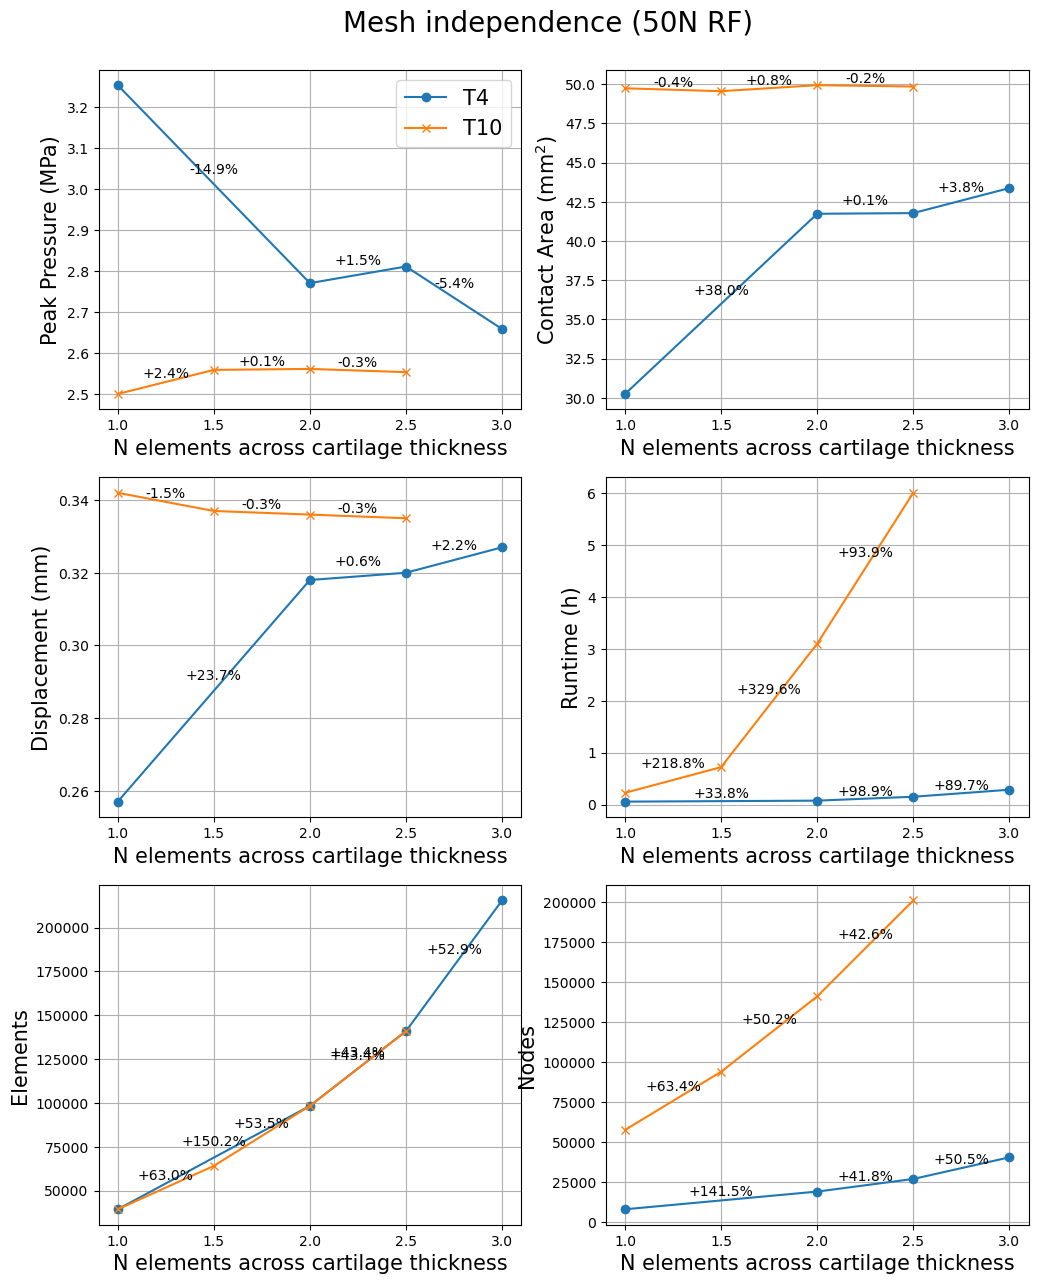

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T0 = [1.0, 2.0, 2.5, 3.0] 
T1 = [1.0, 1.5, 2.0, 2.5]

df0 = pd.DataFrame({x:y for x, y in data.items() if '0' in x})
df1 = pd.DataFrame({x:y for x, y in data.items() if '1' in x})
df0['T0'], df1['T1'] = T0, T1

def annotate_pct_change(ax, x, y, color='black', dy_frac=0.03):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    yspan = np.nanmax(y) - np.nanmin(y)
    dy = dy_frac * yspan if yspan > 0 else dy_frac

    for i in range(len(x) - 1):
        if y[i] == 0:
            continue
        pct = 100 * (y[i+1] - y[i]) / y[i]
        xm = 0.5 * (x[i] + x[i+1])
        ym = 0.5 * (y[i] + y[i+1])
        ax.text(xm, ym + dy, f'{pct:+.1f}%', color=color, fontsize=10,
                ha='center', va='bottom')

nrows, ncols = 3, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
ax = ax.flatten()

series = [
    ('P0', 'P1', 'Peak Pressure (MPa)'),
    ('A0', 'A1', 'Contact Area (mm$^2$)'),
    ('d0', 'd1', 'Displacement (mm)'),
    ('runtime0', 'runtime1', 'Runtime (h)'),
    ('elements0', 'elements1', 'Elements'),
    ('nodes0', 'nodes1', 'Nodes'),
]

for i, (k0, k1, ylabel) in enumerate(series):
    y0 = np.array(data[k0]) / 3600 if 'runtime' in k0 else np.array(data[k0])
    y1 = np.array(data[k1]) / 3600 if 'runtime' in k1 else np.array(data[k1])

    ax[i].plot(T0, y0, marker='o', label='T4')
    ax[i].plot(T1, y1, marker='x', label='T10')

    annotate_pct_change(ax[i], T0, y0)
    annotate_pct_change(ax[i], T1, y1)

    ax[i].set_ylabel(ylabel, fontsize=15)
    ax[i].set_xlabel('N elements across cartilage thickness', fontsize=15)
    ax[i].set_xticks([1.0, 1.5, 2.0, 2.5, 3.0])
    ax[i].grid()

ax[0].legend(fontsize=15)
#plt.tight_layout()
fig.suptitle('Mesh independence (50N RF)', fontsize=20, y=0.92)
plt.show()

In [11]:
df0

,P0,A0,F0,d0,nodes0,elements0,memory0,runtime0,T0
0,3.254196,30.243567,49.080788,0.257,7818,39299,0.527,204.0,1.0
1,2.770512,41.737431,50.026569,0.318,18881,98314,1.758,273.0,2.0
2,2.811105,41.780320,50.024166,0.320,26772,140969,2.749,543.0,2.5
3,2.658406,43.375085,49.999508,0.327,40305,215543,4.789,1030.0,3.0


In [12]:
df1

,P1,A1,F1,d1,nodes1,elements1,memory1,runtime1,T1
0,2.499643,49.740208,49.967850,0.342,57418,39299,6.292,815.0,1.0
1,2.558510,49.555040,49.987915,0.337,93815,64046,11.603,2598.0,1.5
2,2.560888,49.940180,49.987495,0.336,140938,98314,21.227,11161.0,2.0
3,2.552992,49.854352,49.991089,0.335,200942,140969,33.185,21641.0,2.5


In [ ]:
# 3 Tetra across thickness node count
linear_to_quadratic_mesh(pv.read('/Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/outputs/meshInd/study1-final/meshes/50000R/tpm-mc1/3Dmesh/mesh-3T.vtu')).n_points

304986

# Check if feasable for high cell counts

In [ ]:
import subprocess
path_MeshPipeline_main = '../../../../Computational/MeshPipeline/main.py'
subprocess.run(["python", path_MeshPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/MeshPipeline/set_parameters/parameters.json


Full parameter file saved to outputs/element_count/params/full_params.json

SUBJECT: 14874R
	BONES: tpm-mc1
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 3.650s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 7.033s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 22.054s - ok
	BONES: mc1-tpm
		STEP: 2Dmesh
			RUN ID: -0
			Runtime: 1.825s - ok
		STEP: cartilage
			RUN ID: -0-0
			Runtime: 10.626s - ok
		STEP: 3Dmesh
			RUN ID: -0-0-0
			Runtime: 37.113s - ok


CompletedProcess(args=['python', '../../../../Computational/Meshpipeline/main.py'], returncode=0)

In [15]:
import subprocess
path_InpPipeline_main = '../../../../Computational/InpPipeline/main.py'
subprocess.run(["python", path_InpPipeline_main])


Updating parameters.json
	Wrote /Users/maro/Library/CloudStorage/OneDrive-UniversityofLeeds/PhD-wrist/WorkPackages/WorkPackages/TMCJ-Contact/Computational/inpPipeline/set_parameters/parameters.json
Full parameter file saved to outputs/element_count-inp/params/full_params-1.json

SUBJECT: 14874R
	MESH: 0-0-0
		RUN ID: 0
			Runtime: 43.818s - ok


CompletedProcess(args=['python', '../../../../Computational/InpPipeline/main.py'], returncode=0)

In [ ]:
print('SUBJECT: \n\t14874R (Highest element count)\n')

mesh_path = 'outputs/element_count/meshes/14874R/tpm-mc1/3Dmesh/mesh-0-0-0.vtu'
m = pv.read(mesh_path)
m10 = linear_to_quadratic_mesh(m)
print('\tN elements: ', m10.n_cells)
print('\tN vertices: ', m10.n_points)

dat_path = 'outputs/element_count-inp/inpFiles/14874R/inp/0-0-0-neutral-0/0-0-0-neutral-0.dat'
mem = parse_memory_estimate(dat_path)

print('\nMemory required to mimise IO: ', mem['memory_to_minimize_io_gb'], 'GB')
print('     Minimum memory required: ', mem['minimum_memory_required_gb'], 'GB')

SUBJECT: 
	14874R (Highest element count)

	N elements:  294390
	N vertices:  350019

Memory required to mimise IO:  64.782 GB
     Minimum memory required:  3.681 GB
